# Spectral analysis of radiographs

`pynamix.measure` reads a descriptor off the Fourier transform of a radiograph and
calibrates it against known samples. `pynamix.spectral` inverts a forward model of the
same transform,

$$P_X(q) = \langle X \rangle\, v_s\, F^2(qd/2)\, S(q),$$

so the same image gives the solid fraction, the sample thickness, the grain size and a
velocity per species -- two of them with no calibration curve at all.

This notebook works through each of those on synthetic radiographs, where the answer is
known. It also shows the one mistake that will silently ruin every result here.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pynamix.spectral import psd, invert, units, velocity, compat

%matplotlib inline


## A radiograph with a known answer

Fifteen lines of numpy: drop spheres in a periodic box and add up the chords each ray
cuts through them. `centres[:, 0]` is $x$ and lands on axis 1 (columns), which is the
convention `pynamix.spectral.velocity` uses for displacements.


In [2]:
def project(centres, radii, L, n_pixels, supersample=4):
    """Projected solid path length, periodic in the two transverse directions."""
    p = L / n_pixels
    pf = p / supersample
    fine = np.zeros((n_pixels * supersample,) * 2)
    for c, a in zip(centres, radii):
        n = int(np.ceil(a / pf)) + 1
        jc, ic = int(round(c[0] / pf)), int(round(c[1] / pf))  # x -> col, y -> row
        di = np.arange(-n, n + 1)
        xj = (jc + di) * pf + 0.5 * pf - c[0]
        yi = (ic + di) * pf + 0.5 * pf - c[1]
        b2 = yi[:, None] ** 2 + xj[None, :] ** 2
        fine[np.ix_(np.mod(ic + di, n_pixels * supersample),
                    np.mod(jc + di, n_pixels * supersample))] += 2 * np.sqrt(
            np.maximum(a * a - b2, 0.0))
    return fine.reshape(n_pixels, supersample, n_pixels, supersample).mean(axis=(1, 3)), p


Uniformly random centres -- *penetrable* spheres. They are the one case with a closed
form and no free parameters at all: $S(q) \equiv 1$ exactly, so
$P_X(q) = \rho H v_s^2 F^2(qa)$. If the pipeline reproduces that, the transform
normalisation, the pixel transfer function and the absolute amplitude are all right.


In [3]:
rng = np.random.default_rng(0)
L, d, phi = 24.0, 1.0, 0.25
v_s = units.sphere_volume(d)
N = int(phi * L**3 / v_s)
centres = rng.random((N, 3)) * L

X, p = project(centres, np.full(N, d / 2), L, 512)
print(f'{N} spheres, mean X = {X.mean():.4f}, phi*H = {phi * L:.4f}')


6600 spheres, mean X = 5.9996, phi*H = 6.0000


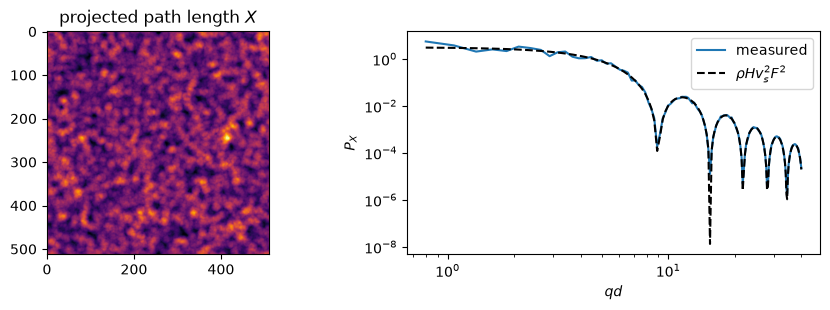

ratio to the analytic result: 1.0104


In [4]:
radial = psd.radial_average(
    psd.deconvolve_pixel_mtf(psd.welch_psd2d(X, p, roi=512, window='boxcar')))

rho = N / L**3
analytic = rho * L * v_s**2 * units.form_factor(radial.q * d / 2) ** 2

fig, ax = plt.subplots(1, 2, figsize=[9, 3.2])
ax[0].imshow(X, cmap='inferno')
ax[0].set_title('projected path length $X$')
ax[1].loglog(radial.q * d, radial.P, label='measured')
ax[1].loglog(radial.q * d, analytic, 'k--', label=r'$\rho H v_s^2 F^2$')
ax[1].set_xlabel('$qd$'); ax[1].set_ylabel('$P_X$'); ax[1].legend()
plt.tight_layout(); plt.show()

band = (radial.q > 1) & (radial.q < 25)
print(f'ratio to the analytic result: {np.median((radial.P / analytic)[band]):.4f}')


## The one mistake to avoid

`pynamix.measure` normalises each patch with `exposure.mean_std` by default. For a peak
*position* that is harmless. Here it is fatal, because the absolute amplitude is what
fixes $\phi$ and the species volume fractions -- and it fails silently: the spectrum
keeps exactly the same shape, so nothing downstream looks wrong.


In [5]:
from pynamix.exposure import mean_std

spoiled = psd.radial_average(
    psd.deconvolve_pixel_mtf(psd.welch_psd2d(mean_std(X), p, roi=512, window='boxcar')))

ratio = spoiled.P / radial.P
print(f'shape unchanged:   spread of the ratio = {np.nanstd(ratio) / np.nanmedian(ratio):.2e}')
print(f'amplitude wrong by a factor {np.nanmedian(ratio):.4f} = 1/var(X) = {1 / X.var():.4f}')


shape unchanged:   spread of the ratio = 9.28e-16
amplitude wrong by a factor 0.2186 = 1/var(X) = 0.2186


In [6]:
try:
    compat.assert_unnormalised(mean_std(X))
except ValueError as e:
    print('caught:', str(e)[:110], '...')


caught: patch looks standardised (mean 3.47e-18, std 1): pynamix.spectral needs an unnormalised projected path length  ...


## The two conventions, side by side

`measure.radial_FFT` *sums* over each annulus, which carries a factor $2\pi q$ and
pushes the apparent peak to shorter wavelengths. `spectral.psd.radial_average` takes the
*mean*, which is what the forward model predicts. Neither is wrong; they are different
quantities, and `compat.annular_sum_to_mean` converts between them.


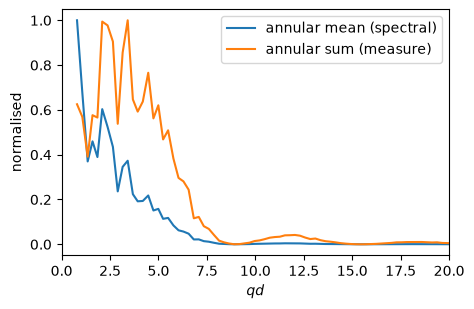

In [7]:
q = radial.q
mean_like = radial.P
sum_like = q * radial.P            # what an annular sum reports

plt.figure(figsize=[5, 3.2])
plt.plot(q * d, mean_like / mean_like.max(), label='annular mean (spectral)')
plt.plot(q * d, sum_like / sum_like.max(), label='annular sum (measure)')
plt.xlim(0, 20); plt.xlabel('$qd$'); plt.ylabel('normalised'); plt.legend()
plt.show()


## Solid fraction: the structure factor and its first peak

Penetrable spheres have no structure, so for this we need grains that exclude each
other. Random sequential addition is enough to produce a real first peak.


In [8]:
def rsa(phi, L, d, rng, batch=3000, max_rounds=400):
    """Random sequential addition: uniformly random, non-overlapping."""
    target = int(phi * L**3 / (np.pi * d**3 / 6))
    acc = np.zeros((0, 3))
    for _ in range(max_rounds):
        keep = []
        for c in rng.random((batch, 3)) * L:
            ok = True
            for pool in (acc, np.array(keep) if keep else np.zeros((0, 3))):
                if len(pool):
                    s = np.abs(pool - c); s = np.minimum(s, L - s)
                    if (np.sum(s**2, axis=1) < d * d).any():
                        ok = False; break
            if ok: keep.append(c)
            if len(acc) + len(keep) >= target: break
        if keep: acc = np.vstack([acc, np.array(keep)])
        if len(acc) >= target: break
    return acc


In [9]:
L = 16.0
centres = rsa(0.32, L, d, np.random.default_rng(1))
phi_true = len(centres) * units.sphere_volume(d) / L**3

X, p = project(centres, np.full(len(centres), d / 2), L, 512)
radial = psd.radial_average(
    psd.deconvolve_pixel_mtf(psd.welch_psd2d(X, p, roi=512, window='boxcar')))

S = invert.recover_S(radial, X.mean(), d, 0.0)
peak = invert.fit_first_peak(S.q, S.S, search=(4.0, 11.0))
print(f'phi = {phi_true:.3f},  q1*d = {peak.q1 * d:.3f},  S(q1) = {peak.S1:.3f}')


phi = 0.320,  q1*d = 6.440,  S(q1) = 1.580


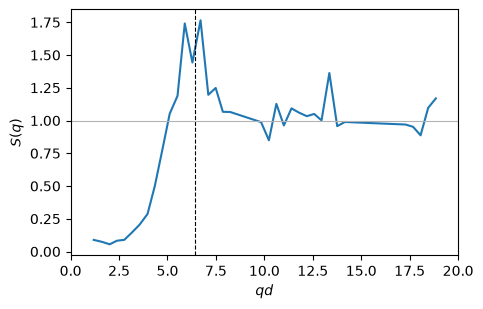

In [10]:
plt.figure(figsize=[5, 3.2])
plt.plot(S.q * d, S.S)
plt.axvline(peak.q1 * d, color='k', ls='--', lw=0.8)
plt.axhline(1.0, color='0.7', lw=0.8)
plt.xlim(0, 20); plt.xlabel('$qd$'); plt.ylabel('$S(q)$')
plt.show()


$q_1 d$ is the descriptor that calibrates against $\phi$ *independently of thickness*,
after which $\hat H = \bar X / \hat\phi$. The calibration $f_1$ is specific to a
preparation protocol and is not a universal equation of state, so it has to be built
from packings made the same way as the sample -- see `pynamix.spectral.calibrate`.
The value above sits below the 7.1-7.6 of a dense jammed packing, as it should: random
sequential addition at $\phi = 0.32$ is a much looser structure.


## Grain size, with no calibration at all

The high-$q$ tail goes to Porod's law, $\tilde\chi \to 2\pi s / q^4$, where $s$ is the
interfacial area per unit volume. That holds for *any* size distribution, so with $\phi$
known the Sauter mean diameter $d_{32} = 6\phi/s$ follows with no model and no
calibration. Here is a bidisperse mixture, $R = 2$.


In [11]:
L = 24.0
d_s, d_l, n_s, n_l = 1.0, 2.0, 9000, 1200
rng = np.random.default_rng(2)
centres = rng.random((n_s + n_l, 3)) * L
radii = np.concatenate([np.full(n_s, d_s / 2), np.full(n_l, d_l / 2)])

X, p = project(centres, radii, L, 512)
radial = psd.radial_average(
    psd.deconvolve_pixel_mtf(psd.welch_psd2d(X, p, roi=512, window='boxcar')))

phi = (n_s * units.sphere_volume(d_s) + n_l * units.sphere_volume(d_l)) / L**3
s_hat = invert.porod_fit(radial, L, (20.0, 45.0))
d32 = 6 * phi / s_hat

diam = np.concatenate([np.full(n_s, d_s), np.full(n_l, d_l)])
print(f'true  d32 = {(diam**3).sum() / (diam**2).sum():.4f}')
print(f'Porod d32 = {d32:.4f}')


true  d32 = 1.3478
Porod d32 = 1.3405


Two things this estimator will not forgive. Use **every** bin in the band: the
zero-avoiding mask needed when *dividing* by $F^2$ deletes the troughs of the
oscillation and biases $s$ high by about a tenth. And where there is photon noise, let a
residual flat floor be a free parameter (`free_floor=True`) -- the $q^4$ weight bears
hardest on the top of the band, where the signal is weakest.

What the tail will *not* give you is the shape of a broad distribution: past a
coefficient of variation of about 0.1 the form-factor oscillations that distinguish two
distributions of equal surface area are damped away, and the two-parameter fit stops
being identifiable. `invert.fit_size_distribution` searches globally by default so that
the failure is visible rather than hidden.


## Velocity from the phase of the cross-spectrum

A rigid translation multiplies every Fourier component by a pure phase, so the phase of
the cross-spectrum between two frames carries the displacement and nothing else. No
particle is tracked.


In [12]:
L = 24.0
rng = np.random.default_rng(5)
centres = rng.random((9000, 3)) * L
radii = np.full(len(centres), d_s / 2)
X1, p = project(centres, radii, L, 512)

print(f"{'true':>16} {'fitted':>20} {'error / d':>10}")
for ux, uy in [(0.05, 0.0), (0.12, 0.0), (0.20, 0.07), (-0.09, 0.15)]:
    moved = centres.copy()
    moved[:, 0] += ux
    moved[:, 1] += uy
    X2, _ = project(np.mod(moved, L), radii, L, 512)
    cs = velocity.welch_cross_spectrum(X1, X2, p, roi=256, window='hann')
    u = velocity.fit_displacement(cs, 1.0, 25.0)
    print(f'({ux:+.2f}, {uy:+.2f})   ({u[0]:+.4f}, {u[1]:+.4f})   {np.hypot(u[0]-ux, u[1]-uy):8.4f}')


            true               fitted  error / d


(+0.05, +0.00)   (+0.0496, -0.0000)     0.0004


(+0.12, +0.00)   (+0.1191, -0.0000)     0.0009


(+0.20, +0.07)   (+0.1984, +0.0694)     0.0017


(-0.09, +0.15)   (-0.0893, +0.1488)     0.0014


Displacements come back ordered `(x, y)` = `(columns, rows)`, so an image whose first
array axis is the physical $x$ will report its motion in the second component.

### Taper your sub-regions

`window='hann'` above is not decoration. Welch averaging cuts sub-regions out of each
frame, and a sub-region has edges even when the parent image does not. With no taper the
leakage from those edges is not displaced with the material, so it dilutes the phase and
the fitted displacement comes out low -- by up to ten per cent here, and worse for smaller
regions. These synthetic images are exactly periodic, so a single region covering the
whole frame has no edges at all and recovers the shift exactly; that is the one case where
a boxcar is safe, and no real radiograph is in it.


In [13]:
ux = 0.12
moved = centres.copy(); moved[:, 0] += ux
X2, _ = project(np.mod(moved, L), radii, L, 512)

for roi, window in [(256, 'boxcar'), (256, 'tukey'), (256, 'hann'), (512, 'boxcar')]:
    cs = velocity.welch_cross_spectrum(X1, X2, p, roi=roi, window=window)
    u = velocity.fit_displacement(cs, 1.0, 25.0)
    note = '  <- whole frame, exactly periodic' if roi == 512 else ''
    print(f'roi={roi:4d}  {window:>7}   {u[0]:.4f}   {100 * (u[0] / ux - 1):+6.1f}%{note}')


roi= 256   boxcar   0.1116     -7.0%
roi= 256    tukey   0.1183     -1.5%
roi= 256     hann   0.1191     -0.8%
roi= 512   boxcar   0.1200     +0.0%  <- whole frame, exactly periodic


## Where to go next

- `pynamix.spectral.uncertainty` -- per-measurement uncertainty, Cramer-Rao bounds and
  coverage testing, rather than an ensemble scatter.
- `pynamix.spectral.closure` -- Percus-Yevick partial structure factors, which supply the
  species weights without a simulation.
- `pynamix.spectral.detector` -- beam hardening, scatter, blur and photon noise, and the
  corrections for them.
- `pynamix.spectral.compat` -- moving between these conventions and those of
  `pynamix.measure`.
